# Track Segmentation for F1 Analysis

This notebook provides a complete workflow for:
1. **Generating track segments** (corners and straights) from raceline data
2. **Visualizing track segments** with comprehensive plots
3. **Aggregating driver telemetry** by track segments

## Key Functions:

- `generate_track_segments(track_name)` - Takes a track name, outputs segments
- `visualize_track_segments(track_name)` - Creates visualizations for a track
- `aggregate_driver_by_segments(segments, track_name, year, driver)` - Aggregates driver stats by segments

## Features:
- Improved corner detection with merging and filtering
- Proper separation of corners and straights (no overlaps)
- Comprehensive driver performance analysis by segment


In [ ]:
# Imports
import fastf1
from fastf1 import plotting
from fastf1.core import Laps
import matplotlib.pyplot as plt

from typing import Iterable, List, Optional
import warnings
import pandas as pd
import numpy as np
import requests
from scipy.signal import find_peaks
import io


## Helper Functions for Raceline Processing


In [2]:
def load_raceline_csv(raw_url: str) -> pd.DataFrame:
    """
    Load raceline CSV and return float columns x_m, y_m.
    Handles comma or semicolon delimiters and coerces numeric types.
    """
    r = requests.get(raw_url, timeout=30)
    r.raise_for_status()

    # Try to auto-detect delimiter (comma or semicolon) & header using the Python engine
    df = pd.read_csv(
        io.StringIO(r.text),
        comment="#",
        sep=None,              # auto-detect delimiter
        engine="python"
    )

    # If there are extra columns, pick the first two numeric-like columns
    # Try common header names first
    possible_x = [c for c in df.columns if str(c).lower() in ("x_m", "x", "xm")]
    possible_y = [c for c in df.columns if str(c).lower() in ("y_m", "y", "ym")]

    if possible_x and possible_y:
        x_col, y_col = possible_x[0], possible_y[0]
    else:
        # Otherwise, take first two columns
        x_col, y_col = df.columns[:2]

    # Coerce to numeric (handles numbers that came in as strings)
    df = df[[x_col, y_col]].copy()
    df.columns = ["x_m", "y_m"]
    df["x_m"] = pd.to_numeric(df["x_m"], errors="coerce")
    df["y_m"] = pd.to_numeric(df["y_m"], errors="coerce")

    # Drop any non-numeric rows that failed coercion
    df = df.dropna(subset=["x_m", "y_m"]).reset_index(drop=True)

    # Ensure it's a closed loop (optional but nice for derivatives)
    if (df.iloc[0] != df.iloc[-1]).any():
        df = pd.concat([df, df.iloc[[0]]], ignore_index=True)

    return df


def arc_length(df: pd.DataFrame) -> pd.Series:
    """Calculate cumulative arc length along the raceline."""
    dx = np.diff(df.x_m, prepend=df.x_m.iloc[0])
    dy = np.diff(df.y_m, prepend=df.y_m.iloc[0])
    return pd.Series(np.cumsum(np.hypot(dx, dy)), name="s_m")


def curvature_from_xy(x: np.ndarray, y: np.ndarray, s: np.ndarray) -> np.ndarray:
    """Calculate curvature from x, y coordinates using arc-length parameterization."""
    # Guard against non-strictly-increasing s
    s = np.maximum.accumulate(s + 1e-12*np.arange(len(s)))
    x_s  = np.gradient(x, s)
    y_s  = np.gradient(y, s)
    x_ss = np.gradient(x_s, s)
    y_ss = np.gradient(y_s, s)
    kappa = np.abs(x_s * y_ss - y_s * x_ss) / np.power(x_s**2 + y_s**2, 1.5)
    # Numerical safety
    kappa = np.nan_to_num(kappa, nan=0.0, posinf=0.0, neginf=0.0)
    return kappa


def resample_equal_arclength(df: pd.DataFrame, step_m: float = 2.0) -> pd.DataFrame:
    """Resample polyline to ~constant spacing along s, improving curvature stability."""
    s = arc_length(df).values
    s_new = np.arange(0, s[-1], step_m)
    # Linear interpolation
    x_new = np.interp(s_new, s, df.x_m.values)
    y_new = np.interp(s_new, s, df.y_m.values)
    out = pd.DataFrame({"s_m": s_new, "x_m": x_new, "y_m": y_new})
    # Close loop exactly
    if (out.iloc[0][["x_m","y_m"]].values != out.iloc[-1][["x_m","y_m"]].values).any():
        out = pd.concat([out, out.iloc[[0]]], ignore_index=True)
        out.loc[out.index[-1], "s_m"] = out["s_m"].iloc[-2] + step_m
    return out


## Improved Corner Detection


In [3]:
def build_improved_corner_segments(
    curv: pd.Series, 
    s: pd.Series, 
    thr_quantile: float = 0.85,
    min_corner_length: float = 10.0,
    merge_distance: float = 20.0
) -> pd.DataFrame:
    """
    Improved corner detection that merges nearby corners and enforces minimum lengths.
    
    Args:
        curv: Curvature series
        s: Arc length series
        thr_quantile: Quantile threshold for identifying corners (0-1)
        min_corner_length: Minimum corner length in meters
        merge_distance: Maximum distance between corners to merge them (meters)
    
    Returns:
        DataFrame with corner segments (start_m, end_m)
    """
    # Threshold to create contiguous 'corner' regions
    thr = np.quantile(curv, thr_quantile)
    is_corner = curv > thr
    
    # Find contiguous corner regions
    segments = []
    run = None
    for si, flag in zip(s.values, is_corner.values):
        if flag and run is None:
            run = {"start_m": si}
        if not flag and run is not None:
            run["end_m"] = prev_s
            segments.append(run)
            run = None
        prev_s = si
    if run is not None:
        run["end_m"] = s.values[-1]
        segments.append(run)
    
    if not segments:
        return pd.DataFrame(columns=['start_m', 'end_m'])
    
    seg_df = pd.DataFrame(segments)
    seg_df['length_m'] = seg_df['end_m'] - seg_df['start_m']
    
    # Filter out segments shorter than minimum length
    seg_df = seg_df[seg_df['length_m'] >= min_corner_length].copy()
    
    if seg_df.empty:
        return pd.DataFrame(columns=['start_m', 'end_m'])
    
    # Sort by start position
    seg_df = seg_df.sort_values('start_m').reset_index(drop=True)
    
    # Merge corners that are very close together
    merged_segments = []
    current_seg = seg_df.iloc[0].to_dict()
    
    for i in range(1, len(seg_df)):
        next_seg = seg_df.iloc[i].to_dict()
        gap = next_seg['start_m'] - current_seg['end_m']
        
        if gap <= merge_distance:
            # Merge: extend current segment to include next one
            current_seg['end_m'] = next_seg['end_m']
            current_seg['length_m'] = current_seg['end_m'] - current_seg['start_m']
        else:
            # Gap is too large, save current and start new
            merged_segments.append(current_seg)
            current_seg = next_seg
    
    # Don't forget the last segment
    merged_segments.append(current_seg)
    
    result_df = pd.DataFrame(merged_segments)
    return result_df[['start_m', 'end_m']]


## Track Segmentation Functions


In [4]:
# Track name to raceline URL mapping (from TUM FTM racetrack database)
TRACK_RACELINE_URLS = {
    "Bahrain": "https://raw.githubusercontent.com/TUMFTM/racetrack-database/master/racelines/Sakhir.csv",
    "Sakhir": "https://raw.githubusercontent.com/TUMFTM/racetrack-database/master/racelines/Sakhir.csv",
    # Add more tracks as needed
    # "Monaco": "...",
    # "Silverstone": "...",
}


def create_straight_segments(corner_segments_df: pd.DataFrame, track_length: float, 
                            min_corner_length: float = 1.0) -> pd.DataFrame:
    """
    Identify straight segments between corner segments.
    
    Filters out zero-length and very small corner segments to avoid overlaps.
    
    Args:
        corner_segments_df: DataFrame with corner segments (start_m, end_m columns)
        track_length: Total track length in meters
        min_corner_length: Minimum corner length to keep (filters out smaller corners)
    
    Returns:
        DataFrame with straight segments
    """
    straight_segments = []
    
    # Filter out zero-length and very small corners to avoid boundary overlaps
    corner_segments_df = corner_segments_df.copy()
    corner_segments_df['length_m'] = corner_segments_df['end_m'] - corner_segments_df['start_m']
    corners_filtered = corner_segments_df[corner_segments_df['length_m'] >= min_corner_length].copy()
    
    if corners_filtered.empty:
        # No valid corners, entire track is a straight
        return pd.DataFrame([{
            'start_m': 0,
            'end_m': track_length,
            'segment_type': 'straight'
        }])
    
    # Sort corners by start position
    corners_sorted = corners_filtered.sort_values('start_m').reset_index(drop=True)
    
    # Add straight before first corner
    if corners_sorted.iloc[0]['start_m'] > 0:
        straight_segments.append({
            'start_m': 0,
            'end_m': corners_sorted.iloc[0]['start_m'],
            'segment_type': 'straight'
        })
    
    # Add straights between corners
    for i in range(len(corners_sorted) - 1):
        current_end = corners_sorted.iloc[i]['end_m']
        next_start = corners_sorted.iloc[i + 1]['start_m']
        
        # Only create straight if there's a gap (strictly greater than)
        if next_start > current_end:
            straight_segments.append({
                'start_m': current_end,
                'end_m': next_start,
                'segment_type': 'straight'
            })
    
    # Add straight after last corner
    last_corner_end = corners_sorted.iloc[-1]['end_m']
    if last_corner_end < track_length:
        straight_segments.append({
            'start_m': last_corner_end,
            'end_m': track_length,
            'segment_type': 'straight'
        })
    
    return pd.DataFrame(straight_segments)


def generate_track_segments(
    track_name: str,
    raceline_url: Optional[str] = None,
    resample_step_m: float = 2.0,
    thr_quantile: float = 0.85,
    min_corner_length: float = 10.0,
    merge_distance: float = 20.0,
    include_straights: bool = True,
    track_length: Optional[float] = None
) -> pd.DataFrame:
    """
    Generate track segments (corners and straights) from raceline data.
    
    Uses improved corner detection that merges nearby corners and properly identifies
    straights as everything that's not a corner.
    
    Args:
        track_name: Name of the track (e.g., "Bahrain")
        raceline_url: Optional URL to raceline CSV. If None, looks up in TRACK_RACELINE_URLS
        resample_step_m: Step size for resampling raceline (meters)
        thr_quantile: Quantile threshold for identifying corners (0-1)
        min_corner_length: Minimum corner length in meters
        merge_distance: Maximum distance between corners to merge them (meters)
        include_straights: If True, also generate straight segments between corners
        track_length: Optional track length in meters. If None, inferred from raceline data
    
    Returns:
        DataFrame with columns: segment_id, segment_type, start_m, end_m, length_m
        segment_type is either 'corner' or 'straight'
    """
    # Get raceline URL
    if raceline_url is None:
        if track_name not in TRACK_RACELINE_URLS:
            raise ValueError(f"Track '{track_name}' not found in TRACK_RACELINE_URLS. "
                           f"Please provide raceline_url or add to mapping.")
        raceline_url = TRACK_RACELINE_URLS[track_name]
    
    # Load and process raceline
    raceline = load_raceline_csv(raceline_url)
    rl_eq = resample_equal_arclength(raceline, resample_step_m)
    
    # Calculate curvature
    kappa = curvature_from_xy(rl_eq.x_m.values, rl_eq.y_m.values, rl_eq.s_m.values)
    rl_eq["kappa"] = kappa
    
    # Build improved corner segments
    corner_segments_df = build_improved_corner_segments(
        rl_eq["kappa"], rl_eq["s_m"],
        thr_quantile=thr_quantile,
        min_corner_length=min_corner_length,
        merge_distance=merge_distance
    )
    
    if corner_segments_df.empty:
        # No corners found, entire track is a straight
        if track_length is None:
            track_length = rl_eq['s_m'].max()
        if not include_straights:
            return pd.DataFrame(columns=['segment_id', 'segment_type', 'start_m', 'end_m', 'length_m'])
        return pd.DataFrame([{
            'segment_id': 0,
            'segment_type': 'straight',
            'start_m': 0.0,
            'end_m': track_length,
            'length_m': track_length
        }])
    
    # Add segment metadata
    corner_segments_df['segment_type'] = 'corner'
    corner_segments_df['length_m'] = corner_segments_df['end_m'] - corner_segments_df['start_m']
    corner_segments_df = corner_segments_df.reset_index(drop=True)
    corner_segments_df['segment_id'] = range(len(corner_segments_df))
    
    if not include_straights:
        return corner_segments_df[['segment_id', 'segment_type', 'start_m', 'end_m', 'length_m']]
    
    # Create straight segments (everything that's not a corner)
    if track_length is None:
        track_length = rl_eq['s_m'].max()
    
    straight_segments = create_straight_segments(corner_segments_df, track_length, min_corner_length=0.0)
    straight_segments['length_m'] = straight_segments['end_m'] - straight_segments['start_m']
    straight_segments = straight_segments.reset_index(drop=True)
    straight_segments['segment_id'] = range(len(straight_segments))
    
    # Combine and sort
    all_segments = pd.concat([
        corner_segments_df[['segment_id', 'segment_type', 'start_m', 'end_m', 'length_m']],
        straight_segments[['segment_id', 'segment_type', 'start_m', 'end_m', 'length_m']]
    ]).sort_values('start_m').reset_index(drop=True)
    
    # Reassign segment IDs sequentially
    all_segments['segment_id'] = range(len(all_segments))
    
    return all_segments


In [5]:
def collect_driver_telemetry(
    year: int,
    grand_prix: str,
    driver: str,
    sessions: Optional[Iterable[str]] = None,
    include_position: bool = False,
    cache_dir: str = "f1_cache",
) -> pd.DataFrame:
    """
    Collect telemetry data for a driver across specified sessions.
    
    Args:
        year: Year of the race
        grand_prix: Name of the grand prix (e.g., "Bahrain")
        driver: Driver 3-letter code (e.g., "VER")
        sessions: Optional list of sessions to include (e.g., ("R",) for race only)
                 Defaults to all sessions
        include_position: Whether to include position data (X, Y, Z coordinates)
        cache_dir: Directory for FastF1 cache
    
    Returns:
        DataFrame with telemetry data including Distance column
    """
    # Reasonable default session list (FastF1 session identifiers)
    if sessions is None:
        sessions = ("FP1", "FP2", "FP3", "Q", "SQ", "SS", "S", "R")

    all_chunks: List[pd.DataFrame] = []

    for sess_name in sessions:
        # Load session (skip if not available for this event/year)
        try:
            session = fastf1.get_session(year, grand_prix, sess_name)
            session.load()
        except Exception as e:
            # Non-existent sessions (e.g., no Sprint) will land here—skip quietly
            warnings.warn(f"Skipping session {sess_name}: {e}")
            continue

        # Filter laps for the driver
        laps = session.laps.pick_driver(driver)
        if laps.empty:
            # Driver may not have participated in this session
            continue

        # Iterate laps and collect per-sample telemetry
        for _, lap in laps.iterlaps():
            try:
                car = lap.get_car_data().add_distance()  # Time, Speed, Throttle, Brake, RPM, nGear, DRS, Source, Distance
                # Add lap-level metadata as columns (broadcast)
                car["Year"] = year
                car["EventName"] = session.event.EventName
                car["SessionName"] = session.name
                car["Driver"] = driver
                car["LapNumber"] = int(lap["LapNumber"])
                # Optional lap attributes (may be NaN for some samples)
                for col in ["Stint", "Compound", "TyreLife", "IsAccurate", "PitInTime", "PitOutTime", "TrackStatus", "LapTime"]:
                    if col in laps.columns:
                        car[col] = lap.get(col, pd.NA)

                if include_position:
                    # Merge position data (X, Y, Z) with car telemetry on Time using merge_asof
                    pos = lap.get_pos_data().sort_values("Time").reset_index(drop=True)
                    car = car.sort_values("Time").reset_index(drop=True)
                    car = pd.merge_asof(
                        car,
                        pos[["Time", "X", "Y", "Z"]],
                        on="Time",
                        direction="nearest",
                        tolerance=pd.Timedelta("50ms"),  # tune if needed
                    )

                all_chunks.append(car)
            except Exception as e:
                warnings.warn(f"Failed telemetry for {driver} lap {int(lap['LapNumber'])} in {session.name}: {e}")
                continue

    if not all_chunks:
        return pd.DataFrame()  # nothing found

    df = pd.concat(all_chunks, ignore_index=True)

    # Nice column ordering (if present)
    preferred_order = [
        "Year", "EventName", "SessionName", "Driver", "LapNumber",
        "Stint", "Compound", "TyreLife", "IsAccurate", "PitInTime", "PitOutTime", "TrackStatus", "LapTime",
        "Time", "Distance", "Speed", "Throttle", "Brake", "nGear", "RPM", "DRS", "Source",
        "X", "Y", "Z"
    ]
    cols = [c for c in preferred_order if c in df.columns] + [c for c in df.columns if c not in preferred_order]
    df = df[cols]

    return df


## Driver Telemetry Collection


In [ ]:
def aggregate_driver_by_segments(
    segments_df: pd.DataFrame,
    track_name: str,
    year: int,
    driver: str,
    sessions: Optional[Iterable[str]] = None,
    include_position: bool = False
) -> pd.DataFrame:
    """
    Aggregate driver telemetry data by track segments for a given track and year.
    
    Args:
        segments_df: DataFrame with segment definitions (from generate_track_segments)
                    Must have columns: segment_id, segment_type, start_m, end_m
        track_name: Name of the track (e.g., "Bahrain")
        year: Year of the race
        driver: Driver 3-letter code (e.g., "VER")
        sessions: Optional list of sessions to include (e.g., ("R",) for race only)
                 Defaults to all sessions
        include_position: Whether to include position data (X, Y, Z coordinates)
    
    Returns:
        DataFrame with aggregated statistics per segment:
        - segment_id, segment_type, start_m, end_m, length_m
        - avg_speed_kmh, max_speed_kmh, min_speed_kmh
        - avg_throttle, brake_percentage
        - avg_rpm, max_rpm, avg_gear
        - drs_usage, sample_count, lap_count
    """
    # Collect driver telemetry
    telemetry_df = collect_driver_telemetry(
        year=year,
        grand_prix=track_name,
        driver=driver,
        sessions=sessions,
        include_position=include_position
    )
    
    if telemetry_df.empty:
        warnings.warn(f"No telemetry data found for {driver} at {track_name} {year}")
        return pd.DataFrame()
    
    # Aggregate by segments
    aggregated_data = []
    
    for _, segment in segments_df.iterrows():
        start_m = segment['start_m']
        end_m = segment['end_m']
        segment_type = segment.get('segment_type', 'unknown')
        
        # Filter telemetry data for this segment
        segment_mask = (telemetry_df['Distance'] >= start_m) & (telemetry_df['Distance'] <= end_m)
        segment_data = telemetry_df[segment_mask]
        
        if segment_data.empty:
            continue
        
        # Use length_m from segments_df if available, otherwise calculate
        length_m = segment.get('length_m', end_m - start_m)
        
        # Calculate aggregated statistics
        # Note: Brake column is boolean (True/False), so .mean() gives brake engagement percentage (0-1)
        # DRS column is integer (0-14), where > 0 indicates DRS is active/available
        stats = {
            'segment_id': segment['segment_id'],
            'segment_type': segment_type,
            'start_m': start_m,
            'end_m': end_m,
            'length_m': length_m,
            'sample_count': len(segment_data),
            'avg_speed_kmh': segment_data['Speed'].mean(),
            'max_speed_kmh': segment_data['Speed'].max(),
            'min_speed_kmh': segment_data['Speed'].min(),
            'avg_throttle': segment_data['Throttle'].mean(),
            'brake_percentage': segment_data['Brake'].mean() * 100,  # Brake engagement percentage (0-100%)
            'avg_rpm': segment_data['RPM'].mean(),
            'max_rpm': segment_data['RPM'].max(),
            'avg_gear': segment_data['nGear'].mean(),
            'drs_usage': (segment_data['DRS'] > 0).mean() * 100,  # DRS active percentage (0-100%)
        }
        
        # Add lap-specific info if available
        if 'LapNumber' in segment_data.columns:
            stats['lap_count'] = len(segment_data['LapNumber'].unique())
        
        aggregated_data.append(stats)
    
    result_df = pd.DataFrame(aggregated_data)
    
    # Add metadata
    if not result_df.empty:
        result_df['track_name'] = track_name
        result_df['year'] = year
        result_df['driver'] = driver
    
    return result_df


## Driver Aggregation by Segments


## Track Visualization Function


In [10]:
def visualize_track_segments(
    track_name: str,
    raceline_url: Optional[str] = None,
    figsize: tuple = (16, 12)
) -> None:
    """
    Create comprehensive visualizations for a track's segments.
    
    Args:
        track_name: Name of the track (e.g., "Bahrain")
        raceline_url: Optional URL to raceline CSV. If None, looks up in TRACK_RACELINE_URLS
        figsize: Figure size tuple (width, height)
    """
    # Generate segments
    segments = generate_track_segments(track_name, raceline_url=raceline_url, include_straights=True)
    corners = segments[segments['segment_type'] == 'corner']
    straights = segments[segments['segment_type'] == 'straight']
    
    # Load raceline data for visualization
    if raceline_url is None:
        if track_name not in TRACK_RACELINE_URLS:
            raise ValueError(f"Track '{track_name}' not found in TRACK_RACELINE_URLS.")
        raceline_url = TRACK_RACELINE_URLS[track_name]
    
    raceline = load_raceline_csv(raceline_url)
    rl_eq = resample_equal_arclength(raceline, 2.0)
    kappa = curvature_from_xy(rl_eq.x_m.values, rl_eq.y_m.values, rl_eq.s_m.values)
    rl_eq["kappa"] = kappa
    
    # Create comprehensive visualization
    fig = plt.figure(figsize=figsize)
    gs = fig.add_gridspec(3, 2, hspace=0.3, wspace=0.3)
    
    # 1. Curvature profile with segments highlighted
    ax1 = fig.add_subplot(gs[0, :])
    ax1.plot(rl_eq['s_m'], rl_eq['kappa'], 'k-', linewidth=1.5, label='Curvature', alpha=0.7)
    ax1.axhline(y=np.quantile(kappa, 0.85), color='r', linestyle='--', alpha=0.5, 
                label='Corner Threshold (85th percentile)')
    
    # Highlight corner segments
    for _, corner in corners.iterrows():
        ax1.axvspan(corner['start_m'], corner['end_m'], alpha=0.3, color='red', 
                   label='Corner' if corner.name == corners.index[0] else '')
    
    # Highlight straight segments
    for _, straight in straights.iterrows():
        ax1.axvspan(straight['start_m'], straight['end_m'], alpha=0.15, color='blue', 
                   label='Straight' if straight.name == straights.index[0] else '')
    
    ax1.set_xlabel('Distance along track (m)', fontsize=12)
    ax1.set_ylabel('Curvature κ (1/m)', fontsize=12)
    ax1.set_title('Track Curvature Profile with Detected Segments', fontsize=14, fontweight='bold')
    ax1.legend(loc='upper right')
    ax1.grid(True, alpha=0.3)
    
    # 2. Track layout (top view) with segments colored
    ax2 = fig.add_subplot(gs[1, 0])
    ax2.plot(rl_eq['x_m'], rl_eq['y_m'], 'k-', linewidth=2, alpha=0.3, label='Track centerline')
    
    # Color track by segment type
    for i, (_, corner) in enumerate(corners.iterrows()):
        mask = (rl_eq['s_m'] >= corner['start_m']) & (rl_eq['s_m'] <= corner['end_m'])
        if mask.any():
            corner_points = rl_eq.loc[mask]
            ax2.plot(corner_points['x_m'], corner_points['y_m'], 'r-', linewidth=3, alpha=0.8)
            # Add corner number
            mid_idx = len(corner_points) // 2
            ax2.text(corner_points.iloc[mid_idx]['x_m'], corner_points.iloc[mid_idx]['y_m'], 
                    f'C{i+1}', fontsize=8, fontweight='bold', color='white',
                    bbox=dict(boxstyle='round', facecolor='red', alpha=0.7))
    
    for _, straight in straights.iterrows():
        mask = (rl_eq['s_m'] >= straight['start_m']) & (rl_eq['s_m'] <= straight['end_m'])
        if mask.any():
            ax2.plot(rl_eq.loc[mask, 'x_m'], rl_eq.loc[mask, 'y_m'], 'b-', linewidth=2, alpha=0.6)
    
    ax2.set_xlabel('X (m)', fontsize=12)
    ax2.set_ylabel('Y (m)', fontsize=12)
    ax2.set_title(f'{track_name} Track Layout: Corners (Red) vs Straights (Blue)', 
                  fontsize=14, fontweight='bold')
    ax2.axis('equal')
    ax2.grid(True, alpha=0.3)
    ax2.legend(['Centerline', 'Corners', 'Straights'], loc='best', fontsize=9)
    
    # 3. Segment length distribution
    ax3 = fig.add_subplot(gs[1, 1])
    corner_lengths = corners['length_m'].values
    straight_lengths = straights['length_m'].values
    
    ax3.hist(corner_lengths, bins=15, alpha=0.7, color='red', 
            label=f'Corners (n={len(corners)})', edgecolor='black')
    ax3.hist(straight_lengths, bins=20, alpha=0.5, color='blue', 
            label=f'Straights (n={len(straights)})', edgecolor='black')
    ax3.set_xlabel('Segment Length (m)', fontsize=12)
    ax3.set_ylabel('Frequency', fontsize=12)
    ax3.set_title('Segment Length Distribution', fontsize=14, fontweight='bold')
    ax3.legend()
    ax3.grid(True, alpha=0.3, axis='y')
    
    # 4. Segment map along track distance
    ax4 = fig.add_subplot(gs[2, 0])
    for i, (_, corner) in enumerate(corners.iterrows()):
        ax4.barh(1, corner['length_m'], left=corner['start_m'], 
                color='red', alpha=0.7, edgecolor='black', linewidth=1)
        mid = (corner['start_m'] + corner['end_m']) / 2
        ax4.text(mid, 1, f"C{i+1}", ha='center', va='center', 
                fontsize=8, fontweight='bold', color='white')
    
    for _, straight in straights.iterrows():
        ax4.barh(0, straight['length_m'], left=straight['start_m'], 
                color='blue', alpha=0.5, edgecolor='black', linewidth=1)
    
    ax4.set_xlabel('Distance along track (m)', fontsize=12)
    ax4.set_ylabel('Segment Type', fontsize=12)
    ax4.set_yticks([0, 1])
    ax4.set_yticklabels(['Straights', 'Corners'])
    ax4.set_title('Segment Map: Position and Length', fontsize=14, fontweight='bold')
    ax4.grid(True, alpha=0.3, axis='x')
    
    # 5. Statistics summary
    ax5 = fig.add_subplot(gs[2, 1])
    ax5.axis('off')
    
    stats_text = f"""
TRACK SEGMENTATION STATISTICS
{'='*40}

CORNERS:
  Count: {len(corners)}
  Total Length: {corners['length_m'].sum():.1f} m
  Average Length: {corners['length_m'].mean():.1f} m
  Min Length: {corners['length_m'].min():.1f} m
  Max Length: {corners['length_m'].max():.1f} m
  % of Track: {100*corners['length_m'].sum()/segments['length_m'].sum():.1f}%

STRAIGHTS:
  Count: {len(straights)}
  Total Length: {straights['length_m'].sum():.1f} m
  Average Length: {straights['length_m'].mean():.1f} m
  Min Length: {straights['length_m'].min():.1f} m
  Max Length: {straights['length_m'].max():.1f} m
  % of Track: {100*straights['length_m'].sum()/segments['length_m'].sum():.1f}%

TOTAL:
  Track Length: {segments['length_m'].sum():.1f} m
  Total Segments: {len(segments)}
  Coverage: 100.0%
"""
    
    ax5.text(0.1, 0.5, stats_text, fontsize=11, family='monospace', 
            verticalalignment='center', 
            bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
    
    plt.suptitle(f'Track Segmentation Analysis - {track_name}', 
                fontsize=16, fontweight='bold', y=0.995)
    plt.show()
    
    print(f"✓ Visualization complete for {track_name}!")
    print(f"  - Detected {len(corners)} corners and {len(straights)} straights")
    print(f"  - Track coverage: 100%")


In [11]:
# Example 1: Generate segments for a track
print("Example 1: Generating track segments for Bahrain")
segments = generate_track_segments('Bahrain', include_straights=True)
print(f"Generated {len(segments)} segments")
print(f"  - Corners: {len(segments[segments['segment_type'] == 'corner'])}")
print(f"  - Straights: {len(segments[segments['segment_type'] == 'straight'])}")
print("\nFirst few segments:")
print(segments.head(10))


Example 1: Generating track segments for Bahrain
Generated 21 segments
  - Corners: 10
  - Straights: 11

First few segments:
   segment_id segment_type  start_m   end_m  length_m
0           0     straight      0.0   690.0     690.0
1           1       corner    690.0   774.0      84.0
2           2     straight    774.0   808.0      34.0
3           3       corner    808.0   856.0      48.0
4           4     straight    856.0  1474.0     618.0
5           5       corner   1474.0  1570.0      96.0
6           6     straight   1570.0  1842.0     272.0
7           7       corner   1842.0  1888.0      46.0
8           8     straight   1888.0  1974.0      86.0
9           9       corner   1974.0  1988.0      14.0


Example 2: Visualizing track segments


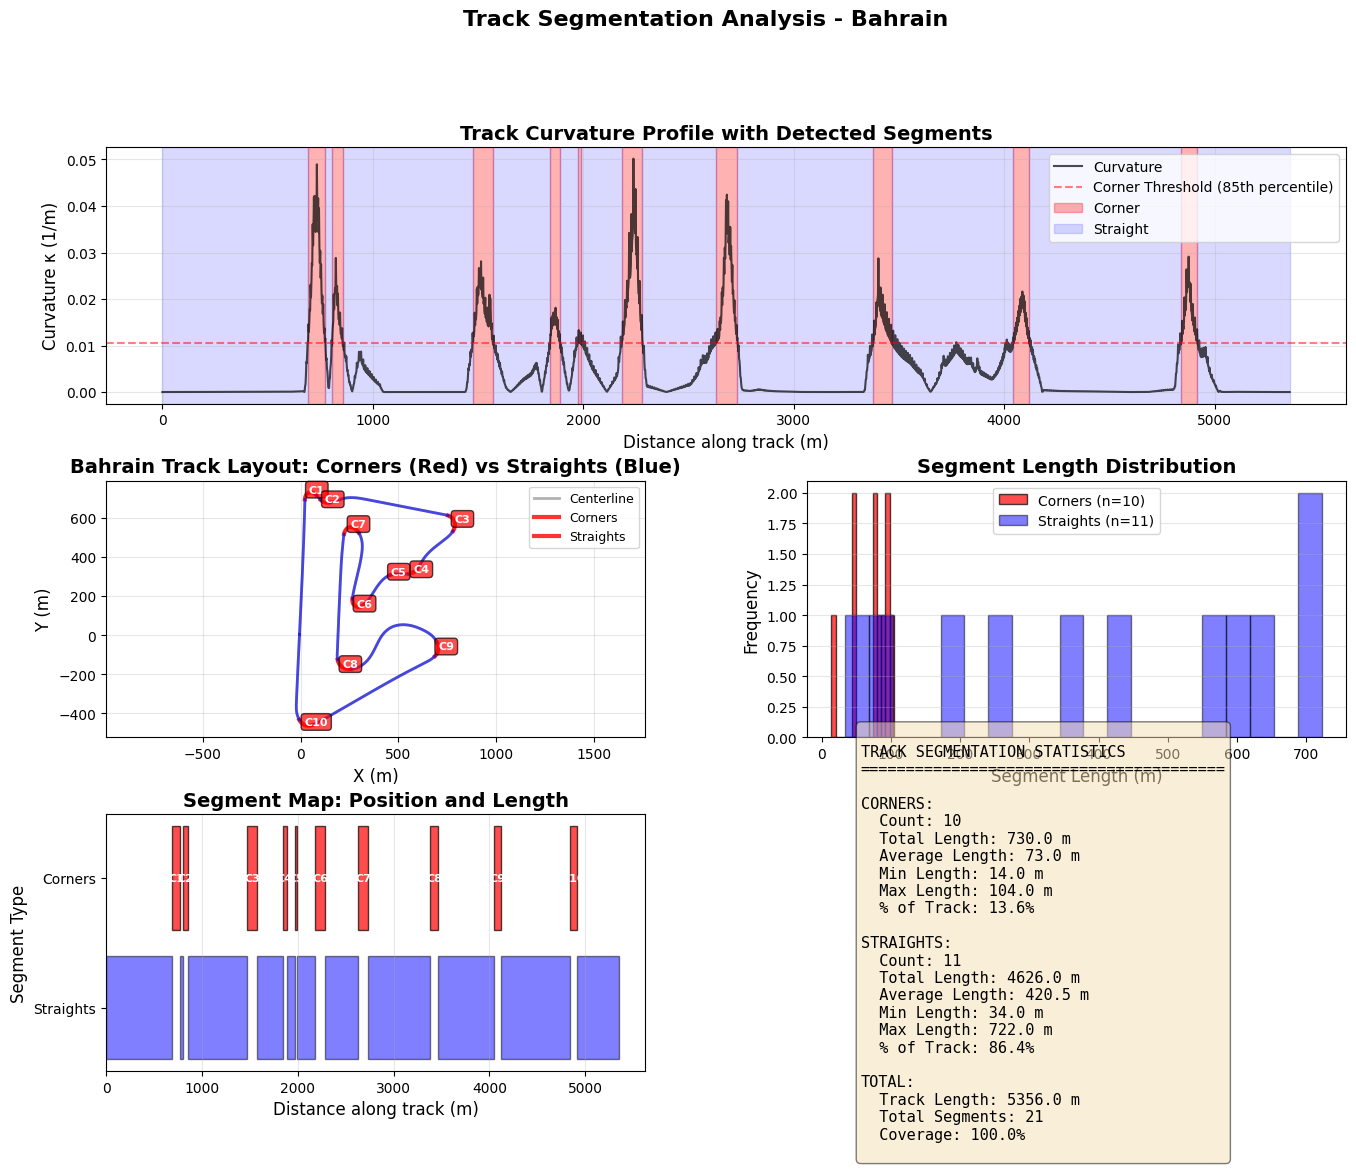

✓ Visualization complete for Bahrain!
  - Detected 10 corners and 11 straights
  - Track coverage: 100%


In [12]:
# Example 2: Visualize track segments
print("Example 2: Visualizing track segments")
visualize_track_segments('Bahrain')


In [13]:
# Example 3: Aggregate driver data by segments
print("\nExample 3: Aggregating VER's race data by segments")
ver_stats = aggregate_driver_by_segments(
    segments_df=segments,
    track_name='Bahrain',
    year=2024,
    driver='VER',
    sessions=('R',),  # Race only
    include_position=False
)

print(f"\nAggregated data for {len(ver_stats)} segments")
print("\nSummary statistics:")
print(ver_stats[['segment_id', 'segment_type', 'start_m', 'end_m', 
                 'avg_speed_kmh', 'avg_throttle', 'brake_percentage']].head(10))



Example 3: Aggregating VER's race data by segments


logger      WARNING 	Failed to load schedule from FastF1 backend!
req            INFO 	No cached data found for season_schedule. Loading data...
_api           INFO 	Fetching season schedule...
req            INFO 	Data has been written to cache!
events      WARNING 	Correcting user input 'Bahrain' to 'São Paulo Grand Prix'
core           INFO 	Loading data for São Paulo Grand Prix - Race [v3.6.1]
req            INFO 	No cached data found for session_info. Loading data...
_api           INFO 	Fetching session info data...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for driver_info. Loading data...
_api           INFO 	Fetching driver list...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for session_status_data. Loading data...
_api           INFO 	Fetching session status data...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for lap_count. 


Aggregated data for 19 segments

Summary statistics:
   segment_id segment_type  start_m   end_m  avg_speed_kmh  avg_throttle  \
0           0     straight      0.0   690.0     159.547589     35.758431   
1           1       corner    690.0   774.0     220.291785     87.719547   
2           2     straight    774.0   808.0     235.671642     91.462687   
3           3       corner    808.0   856.0     247.085227     93.988636   
4           4     straight    856.0  1474.0     207.436838     46.569866   
5           5       corner   1474.0  1570.0     172.780392     86.421569   
6           6     straight   1570.0  1842.0     227.774340     87.035487   
7           7       corner   1842.0  1888.0     252.700000     81.743750   
8           8     straight   1888.0  1974.0     218.255937      8.274406   
9           9       corner   1974.0  1988.0     179.337838      0.959459   

   brake_percentage  
0         28.728454  
1          1.699717  
2          0.000000  
3          0.000000  

In [ ]:
# Example 4: Compare corner vs straight performance
print("\nExample 4: Performance comparison")
corner_stats = ver_stats[ver_stats['segment_type'] == 'corner']
straight_stats = ver_stats[ver_stats['segment_type'] == 'straight']

if not corner_stats.empty:
    print(f"\nCORNERS ({len(corner_stats)} segments):")
    print(f"  Avg speed: {corner_stats['avg_speed_kmh'].mean():.1f} km/h")
    print(f"  Avg throttle: {corner_stats['avg_throttle'].mean():.1f}%")
    print(f"  Brake usage: {corner_stats['brake_percentage'].mean():.1f}%")

if not straight_stats.empty:
    print(f"\nSTRAIGHTS ({len(straight_stats)} segments):")
    print(f"  Avg speed: {straight_stats['avg_speed_kmh'].mean():.1f} km/h")
    print(f"  Avg throttle: {straight_stats['avg_throttle'].mean():.1f}%")
    print(f"  Brake usage: {straight_stats['brake_percentage'].mean():.1f}%")
